# TASK 02 — Gradient Descent From Scratch

In this task, I will build a reusable gradient descent optimizer from scratch.

The optimizer will:
- accept a gradient function
- accept a starting position
- use a learning rate
- perform a fixed number of updates
- return the complete history of positions

I will first minimize:

f(x) = (x - 5)^2

whose gradient is:

f'(x) = 2(x - 5)

The known minimum is x = 5.

## The Gradient Descent Update Rule

Gradient descent updates the current position using:

x_new = x_old - learning_rate * gradient

The gradient tells us the direction of steepest increase.

Therefore, subtracting the gradient moves us toward lower function values.

The learning rate controls the size of each step.

First six positions:
Step 0: x = 0.000000
Step 1: x = 1.000000
Step 2: x = 1.800000
Step 3: x = 2.440000
Step 4: x = 2.952000
Step 5: x = 3.361600

Final position:
x = 4.942354

Known minimum:
x = 5

Distance from minimum:
0.057646


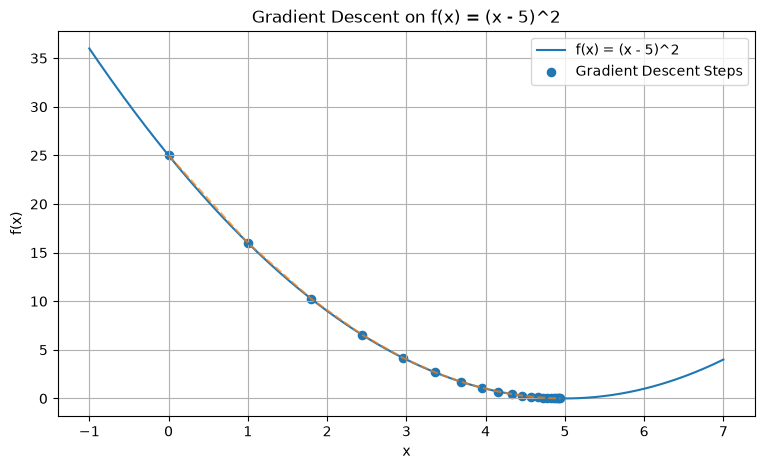



SECOND FUNCTION
----------------
First six positions:
Step 0: x = 5.000000
Step 1: x = 3.400000
Step 2: x = 2.120000
Step 3: x = 1.096000
Step 4: x = 0.276800
Step 5: x = -0.378560

Final position:
x = -2.990096

Known minimum:
x = -3

Distance from minimum:
0.009904


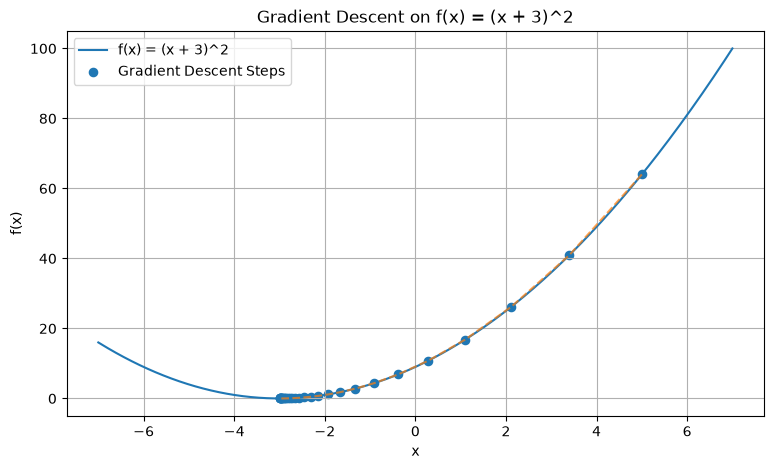

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------
# Reusable Gradient Descent Optimizer
# --------------------------------------------------

def gradient_descent(grad_fn, start, lr, steps):
    x = start
    history = [x]

    for _ in range(steps):
        gradient = grad_fn(x)
        x = x - lr * gradient
        history.append(x)

    return history


# --------------------------------------------------
# TASK 02 - Function 1
# f(x) = (x - 5)^2
# gradient = 2(x - 5)
# --------------------------------------------------

def f1(x):
    return (x - 5) ** 2


def grad_f1(x):
    return 2 * (x - 5)


# Run gradient descent
history1 = gradient_descent(
    grad_fn=grad_f1,
    start=0,
    lr=0.1,
    steps=20
)

# Convert history to NumPy array
history1 = np.array(history1)

# Print first six positions
print("First six positions:")

for i, x in enumerate(history1[:6]):
    print(f"Step {i}: x = {x:.6f}")

# Final position
print("\nFinal position:")
print(f"x = {history1[-1]:.6f}")

print("\nKnown minimum:")
print("x = 5")

print("\nDistance from minimum:")
print(f"{abs(history1[-1] - 5):.6f}")


# --------------------------------------------------
# Plot function and gradient descent path
# --------------------------------------------------

x_values = np.linspace(-1, 7, 400)
y_values = f1(x_values)

plt.figure(figsize=(9, 5))

# Function curve
plt.plot(
    x_values,
    y_values,
    label="f(x) = (x - 5)^2"
)

# Gradient descent points
plt.scatter(
    history1,
    f1(history1),
    s=35,
    label="Gradient Descent Steps"
)

# Connect the steps
plt.plot(
    history1,
    f1(history1),
    linestyle="--",
    alpha=0.7
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent on f(x) = (x - 5)^2")
plt.legend()
plt.grid(True)
plt.show()


# --------------------------------------------------
# TASK 02 - Function 2
# f(x) = (x + 3)^2
# Known minimum: x = -3
# --------------------------------------------------

def f2(x):
    return (x + 3) ** 2


def grad_f2(x):
    return 2 * (x + 3)


history2 = gradient_descent(
    grad_fn=grad_f2,
    start=5,
    lr=0.1,
    steps=30
)

history2 = np.array(history2)

print("\n\nSECOND FUNCTION")
print("----------------")

print("First six positions:")

for i, x in enumerate(history2[:6]):
    print(f"Step {i}: x = {x:.6f}")

print("\nFinal position:")
print(f"x = {history2[-1]:.6f}")

print("\nKnown minimum:")
print("x = -3")

print("\nDistance from minimum:")
print(f"{abs(history2[-1] + 3):.6f}")


# Plot second function
x_values2 = np.linspace(-7, 7, 400)
y_values2 = f2(x_values2)

plt.figure(figsize=(9, 5))

plt.plot(
    x_values2,
    y_values2,
    label="f(x) = (x + 3)^2"
)

plt.scatter(
    history2,
    f2(history2),
    s=35,
    label="Gradient Descent Steps"
)

plt.plot(
    history2,
    f2(history2),
    linestyle="--",
    alpha=0.7
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent on f(x) = (x + 3)^2")
plt.legend()
plt.grid(True)
plt.show()

## Results

For the first function:

f(x) = (x - 5)^2

the optimizer starts at x = 0 and moves toward the known minimum x = 5.

The first few positions should show that the jumps become progressively smaller.

This happens because the gradient:

2(x - 5)

becomes closer to zero as x approaches 5.

The optimizer therefore takes smaller steps near the minimum.

## Understanding the Result

### Why do the steps automatically get smaller near the minimum?

The gradient becomes smaller as the position approaches the minimum, so the update `lr * gradient` also becomes smaller.

### What is the gradient at the exact minimum?

For f(x) = (x - 5)^2:

gradient = 2(x - 5)

At x = 5:

gradient = 0

Therefore the update is zero and the optimizer stops moving.

### What happens if we start exactly at the minimum?

If we start at x = 5, the gradient is already zero. Every update is therefore zero, so x remains 5.

### Second function

I also tested:

f(x) = (x + 3)^2

Its known minimum is x = -3.

The same reusable optimizer successfully moves from x = 5 toward x = -3.

This demonstrates that the optimizer is reusable and does not depend specifically on the first function.